# Imports

In [1]:
import gensim
import ujson as json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import logging
from collections import defaultdict
sns.set(style='white', context='notebook', rc={'figure.figsize':(14,10)})
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

In [2]:
LOAD_FROM_FILE = False
DATAFRAME_FILE = '..data/flavor_space.parquet'
FLAVMOL_FILE = '..data/flavor_mol.parquet'
MODEL_FILES = {'cbow': '../data/flavor2vec-cbow.model'}

In [3]:
## fix issue when different version of gensim is used
from pip._vendor import pkg_resources

def get_version(package):
    package = package.lower()
    return next((p.version for p in pkg_resources.working_set if p.project_name.lower() == package), "No match")
gensim_version = int(get_version("gensim").split(".")[0])
print(gensim_version)

4


# Prepare datasets

In [5]:
with open('../data_prep/full_set.json') as f:
        data = json.load(f)
        df = pd.json_normalize(data)
        df = df.astype({'id': 'string'})
df.head()

,id,food,unique_ingredient,ingredient_count,category_freq,instructions,flavor_molecules,molecules_count,nutr_values_per100g.energy,nutr_values_per100g.fat,nutr_values_per100g.protein,nutr_values_per100g.salt,nutr_values_per100g.saturates,nutr_values_per100g.sugars,fsa_lights_per100g.fat,fsa_lights_per100g.salt,fsa_lights_per100g.saturates,fsa_lights_per100g.sugars
0,000095fc1d,Yogurt Parfaits,"[yogurt, greek, plain, nonfat, strawberries, r...",3,"[{'additive': 1}, {'dairy': 1}, {'fruit-berry'...",[{'text': 'Layer all ingredients in a serving ...,"[{'ingredient_flavorDB': 'Strawberry', 'fooddb...",268,81.129461,2.140139,6.914437,0.055978,0.365347,5.086341,green,green,green,orange
1,00051d5b9d,"Salt Free, Low Cholesterol Sugar Cookies Recipe","[sugars, granulated, oil, corn, peanut, and ol...",6,"[{'additive': 2}, {'animalproduct': 1}, {'cere...",[{'text': 'Cream sugar and butter together til...,"[{'ingredient_flavorDB': 'Wheat', 'fooddb_id':...",303,477.096404,23.412486,7.625492,0.548621,3.425054,14.298443,red,orange,orange,orange
2,00059b093b,Honey Sriracha Chicken Wings,"[chicken, broilers or fryers, wing, meat and s...",11,"[{'additive': 4}, {'cerealcrop-cereal': 1}, {'...","[{'text': 'Preheat oven to 400 degrees F.'}, {...","[{'ingredient_flavorDB': 'Pepper', 'fooddb_id'...",513,208.058983,14.297046,15.383456,1.063915,4.535687,3.048951,orange,orange,orange,green
3,0005fc89f7,Shrimp and Caper Salad,"[crustaceans, shrimp, raw (not previously froz...",8,"[{'dish': 2}, {'fishseafood-seafood': 1}, {'fr...","[{'text': 'In a large bowl, toss the shrimp, g...","[{'ingredient_flavorDB': 'Lemon', 'fooddb_id':...",368,194.752596,15.980767,11.946687,0.614843,2.366704,0.314583,orange,orange,orange,green
4,0006ca31f4,Natural Peanut Butter Chocolate Bon Bons,"[cocoa, dry powder, unsweetened, honey, peanut...",3,"[{'dairy': 1}, {'plantderivative': 2}]",[{'text': 'Measure out the cocoa powder into a...,"[{'ingredient_flavorDB': 'Honey', 'fooddb_id':...",170,303.435400,5.094847,5.067961,0.019791,2.048394,63.210605,orange,green,orange,red


In [7]:
with open('../data_prep/flavor_DB.json') as f:
        data = json.load(f)
        flavor_df = pd.json_normalize(data)
flavor_df.head()


,category,entity_id,category_readable,entity_alias_basket,entity_alias_readable,natural_source_name,entity_alias,molecules,natural_source_url,entity_alias_url,entity_alias_synonyms
0,animalproduct,0,Animal Product,"egg, egg-boiled, egg-cooked, egg-scrambled",Egg,Chicken,egg,"[{'bond_stereo_count': 0, 'undefined_atom_ster...",https://en.wikipedia.org/wiki/Chicken,https://en.wikipedia.org/wiki/Egg_as_food,Egg
1,bakery,1,Bakery,bakery-products,Bakery Products,Poacceae,bakery,"[{'bond_stereo_count': 0, 'undefined_atom_ster...",https://en.wikipedia.org/wiki/Poaceae,https://en.wikipedia.org/wiki/Bakery,Bakery Products
2,bakery,2,Bakery,"bread, bread-preferment",Bread,Poacceae,bread,"[{'bond_stereo_count': 0, 'undefined_atom_ster...",https://en.wikipedia.org/wiki/Poaceae,https://en.wikipedia.org/wiki/Bread,Bread
3,bakery,3,Bakery,bread-rye,Rye Bread,Rye,bread-rye,"[{'bond_stereo_count': 0, 'undefined_atom_ster...",https://en.wikipedia.org/wiki/Rye,https://en.wikipedia.org/wiki/Rye_bread,Rye Bread
4,bakery,4,Bakery,bread-wheaten,Wheaten Bread,Wheat,bread-wheaten,"[{'bond_stereo_count': 0, 'undefined_atom_ster...",https://en.wikipedia.org/wiki/Wheat,https://en.wikipedia.org/wiki/Soda_bread,"Soda scones, Soda farls"


In [4]:
LOAD_FROM_FILE=True
if LOAD_FROM_FILE:
    df = pd.read_parquet(DATAFRAME_FILE)
    mol_df = pd.read_parquet(FLAVMOL_FILE)
else:
    with open('../data_prep/full_set.json') as f:
        data = json.load(f)
        df = pd.json_normalize(data)
        df = df.astype({'id': 'string'})
        # Construct Molecule vectors
        df['mols'] = df['flavor_molecules'].apply(lambda el: [str(m['pubchem_id']) for m in el])        
        df['type'] = 'recipe'

    with open('../data_prep/flavor_DB.json') as f:
        data = json.load(f)
        flavor_df = pd.json_normalize(data)
        flavor_df = flavor_df.rename(columns={'entity_id': 'id', 'entity_alias_readable': 'food'})
        flavor_df['id'] = flavor_df['id'].apply(lambda i: f"ing-{i}" )
        # Construct Document vectors
        flavor_df['mols'] = flavor_df['molecules'].apply(lambda el: [str(m['pubchem_id']) for m in el])        
        # Annotate documnet lengths
        flavor_df['molecules_count'] = flavor_df['mols'].apply(lambda el: len(el))
        flavor_df['type'] = 'ingredient'
        mol_df =  pd.DataFrame(list(flavor_df.molecules.explode())).drop_duplicates(subset=['pubchem_id'])

    df.head()   
    df = pd.concat([df, flavor_df])
    
    df.reset_index(drop=True, inplace=True)    
    del flavor_df, data
    
# Build Tagged Document Corpus
df['mol_doc'] = df.apply(lambda r: gensim.models.doc2vec.TaggedDocument(r['mols'], [r['id']]), axis=1)    
df

FileNotFoundError: [Errno 2] No such file or directory: 'data/flavor_space.parquet'

# HyperParameters

In [3]:
MODEL = 'cbow'
VECTOR_SIZE = 100
WINDOW_SIZE = df['molecules_count'].max() 
print(WINDOW_SIZE)
EPOCHS = 40
DIM_REDUCTION = 3

NameError: name 'df' is not defined

# Train Model

In [15]:
LOAD_FROM_FILE=True

if LOAD_FROM_FILE:
    model = gensim.models.doc2vec.Doc2Vec.load(MODEL_FILES[MODEL])
else:
    m = {'cbow': 0, 'skip': 1}[MODEL]
    model = gensim.models.doc2vec.Doc2Vec(dm=m, vector_size=VECTOR_SIZE, window=WINDOW_SIZE, epochs=EPOCHS)
    model.build_vocab(df['mol_doc'])
    model.train(df['mol_doc'], total_examples=model.corpus_count, epochs=model.epochs)
    model.save(MODEL_FILES[MODEL])

2023-10-15 20:51:11,731 : INFO : loading Doc2Vec object from ../data/flavor2vec-cbow.model
2023-10-15 20:51:12,944 : INFO : loading dv recursively from ../data/flavor2vec-cbow.model.dv.* with mmap=None
2023-10-15 20:51:12,945 : INFO : loading wv recursively from ../data/flavor2vec-cbow.model.wv.* with mmap=None
2023-10-15 20:51:12,946 : INFO : setting ignored attribute cum_table to None
2023-10-15 20:51:12,965 : INFO : Doc2Vec lifecycle event {'fname': '../data/flavor2vec-cbow.model', 'datetime': '2023-10-15T20:51:12.965085', 'gensim': '4.0.1', 'python': '3.9.18 (main, Sep 11 2023, 08:38:23) \n[Clang 14.0.6 ]', 'platform': 'macOS-10.11.6-x86_64-i386-64bit', 'event': 'loaded'}


# Random Flavor Neighborhood

In [21]:

def random_suggestion():
    row = df.sample(n=1)
    flavor_vec = model.infer_vector(row.iloc[0]['mol_doc'].words)
    if gensim_version >= 4:
         similars = model.dv.most_similar(positive=[flavor_vec])
    else:
        similars = model.dv.most_similar(flavor_vec)
   
    s_df = pd.DataFrame(similars, columns=['id','similarity']).astype({'id': 'string'})
    return pd.concat([row[['id','food']], s_df.merge(df, on='id', how='left')[['id','similarity','food']] ])
random_suggestion()

,id,food,similarity
3860,1346fe1f83,Better Burgers,NaN
0,ea96d66478,Texas Barbecued Brisket,0.967245
1,04a9412ec9,Homemade Steak Rub,0.964807
2,036a25db55,Everyday Seasoning,0.964578
3,de2aafcaf4,Miss Tink's House Seasoning,0.958710
4,e52511c62e,Jalapeno Salt,0.958588
5,bb65d206fd,E.j.'s Barbecue Dry Rub,0.956505
6,d857754d56,Steak seasoning,0.954002
7,baba429fd4,Basic Chicken Rub,0.952772
8,446e231dac,Jerky Home Style,0.951502


# Identity Accuracy (Top-k ROC)

# Dimensional Reduction

In [1]:
import umap.umap_ as umap

/Users/Justin/opt/anaconda3/envs/f_app/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
reducer = umap.UMAP(n_components=DIM_REDUCTION)
projection = reducer.fit_transform(model.dv.vectors) # model.dv.index_to_key 
projection
projection.shape

NameError: name 'DIM_REDUCTION' is not defined

# Clustering Analysis

In [18]:
from sklearn.cluster import DBSCAN
from matplotlib import cm

### PV-DM Model

In [76]:
skip = gensim.models.doc2vec.Doc2Vec.load(MODEL_FILES['skip'])
skip_projection = reducer.fit_transform(skip.dv.vectors) # model.dv.index_to_key 

skip_clustering_df = pd.DataFrame(skip_projection, columns=('x', 'y','z'))
skip_clustering = DBSCAN(eps=.2, min_samples=10, n_jobs=-1).fit(skip_clustering_df[['x','y','z']])
skip_clustering_df['cluster'] = skip_clustering.fit_predict(skip_clustering_df[['x','y','z']])
num_clusters = len(skip_clustering_df['cluster'].unique())

cmap = cm.get_cmap('prism', num_clusters)
plt.scatter(skip_clustering_df['x'], skip_clustering_df['y'], 
            marker='.', alpha=1,
            c=skip_clustering_df['cluster'], 
            cmap=cmap
           )
plt.title(f"PV-DM clusters ({num_clusters})", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

2023-05-29 15:58:54,348 : INFO : loading Doc2Vec object from ../data/flavor2vec-skipgram.model


FileNotFoundError: [Errno 2] No such file or directory: '../data/flavor2vec-skipgram.model'

### CBOW Model

(array([-15., -10.,  -5.,   0.,   5.,  10.,  15.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

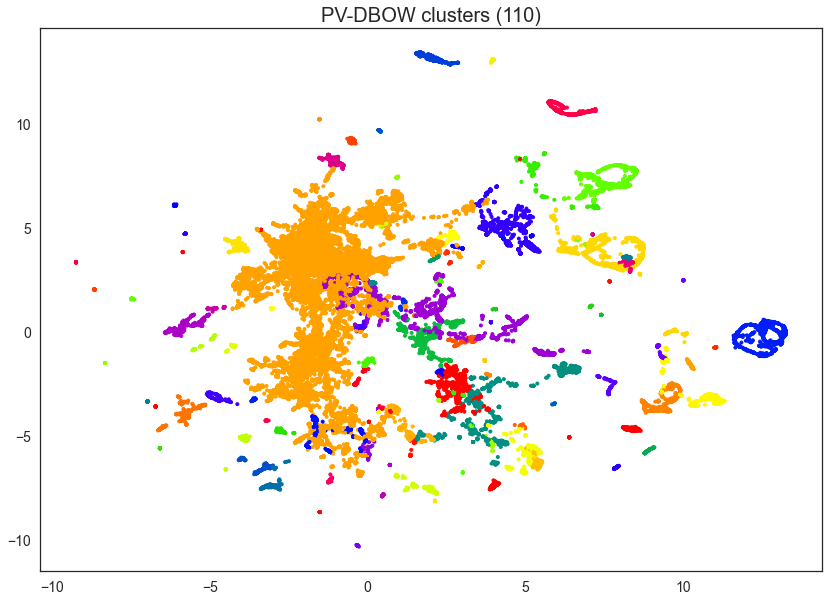

In [56]:
clustering_df = pd.DataFrame(projection, columns=('x', 'y','z'))
clustering = DBSCAN(eps=.8, min_samples=10, n_jobs=-1).fit(clustering_df[['x','y','z']])
clustering_df['cluster'] = clustering.fit_predict(clustering_df[['x','y','z']]) = len(clustering_df['cluster'].unique())

cmap = cm.get_cmap('prism', num_clusters)
plt.scatter(clustering_df['x'], clustering_df['y'], 
            marker='.', alpha=1,
            c=clustering_df['cluster'], 
            cmap=cmap
           )
plt.title(f"PV-DBOW clusters ({num_clusters})", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

In [57]:
TOPN_CLUSTERS = 25

cluster_groups = clustering_df['cluster'].value_counts().T
cluster_groups = pd.DataFrame(cluster_groups)
cluster_groups = cluster_groups.reset_index()
cluster_groups.columns = ['cluster', 'items']
cluster_groups = cluster_groups.sort_values(by='items', ascending=False)
cluster_groups = cluster_groups[:TOPN_CLUSTERS]

def rgba(e):
    index = e[0]
    return (
        cmap(index)[0]*255,
        cmap(index)[1]*255,
        cmap(index)[2]*255,
        cmap(index)[3],        
    )

_flav_df = pd.merge(df, clustering_df['cluster'], left_index=True, right_index=True)

def flav_freq(row):
    terms = defaultdict(int)
    total = 0
    for j, r in _flav_df[(_flav_df.cluster == row.cluster) & (_flav_df.type == 'recipe')].iterrows():
        for m in r.flavor_molecules:
            ts = m['flavor_profile'].split('@')
            for t in ts:
                terms[t] += 1
                total += 1

    topn = dict(map(lambda e: (e[0], e[1]/total), sorted(terms.items(), key=lambda e: e[1], reverse=True)))
    return topn


cluster_groups['flav_freq'] = cluster_groups.apply(flav_freq, axis=1)
cluster_groups['total_mols'] = cluster_groups.apply(lambda r: len(_flav_df[_flav_df.cluster == r['cluster']].mols.explode().unique()), axis=1)
cluster_groups['color'] = cluster_groups.apply(rgba, axis=1)
cluster_groups['swatch'] = ['&#9608;'] * len(cluster_groups)

### Molecular Taste Distribution 

In [58]:
def taste_distribution(df):
    mol_flavors = defaultdict(int)
    for flavor_profile in df.flavor_profile:
        if type(flavor_profile) is str:
            flavors = flavor_profile.split('@')
            for flavor in flavors:
                mol_flavors[flavor] +=1
            
    total_mols = len(df)
    for k,v in mol_flavors.items():
        mol_flavors[k] = v/total_mols
        
    return pd.DataFrame(
        sorted(mol_flavors.items(), key=lambda e: e[1], reverse=True),
        columns=['taste', 'coverage']
    )

taste_dist = taste_distribution(mol_df)

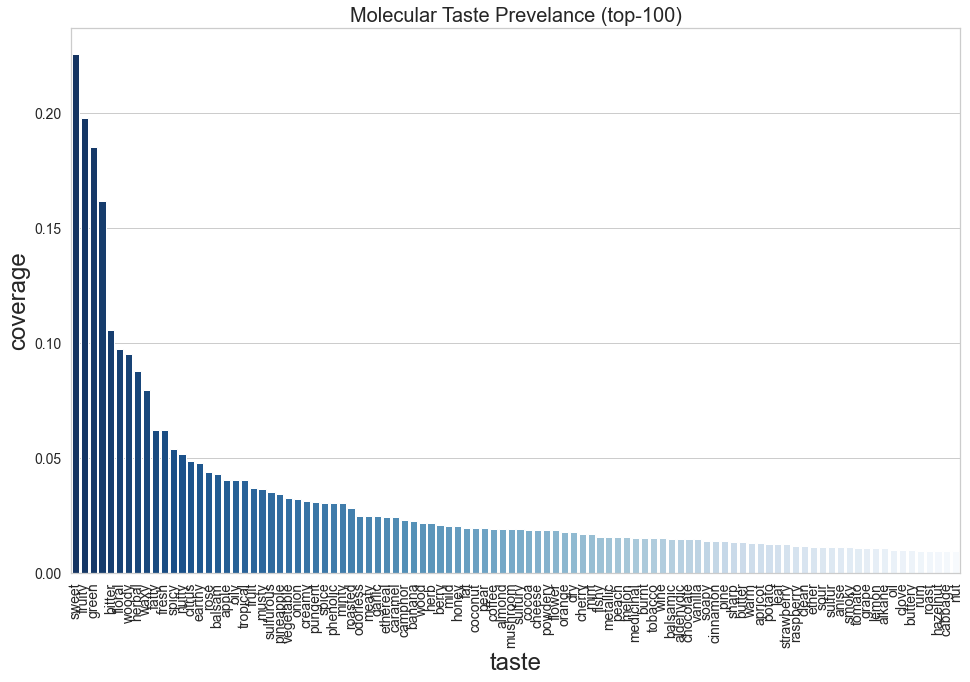

In [59]:
sns.set(font_scale = 2)
sns.set_style("whitegrid")

sns.barplot(x="taste", y="coverage", data=taste_dist[0:100], palette="Blues_r")
plt.xticks(rotation=90)
plt.title(f"Molecular Taste Prevelance (top-100)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()

In [60]:
from bokeh.application import Application
from bokeh.application.handlers import FunctionHandler
from bokeh.layouts import column, row
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import ( 
    HoverTool, ColumnDataSource, Callback, DataTable, TableColumn,
    CustomJS, CategoricalColorMapper, CategoricalMarkerMapper, LinearColorMapper, Div
)
from bokeh.transform import linear_cmap
from bokeh.palettes import Cividis256, Magma256
from bokeh.models.widgets import Slider, TextInput, Select, AutocompleteInput, HTMLTemplateFormatter

logging.getLogger('bokeh').setLevel(logging.CRITICAL)
logging.getLogger('tornado').setLevel(logging.CRITICAL)

output_notebook()

Loading BokehJS ...

In [61]:
"""
TF-IDF Adapted for cluster term enrichment as term frequencey - inverse cluster frequencey
"""  

def doc_freq(df):
    terms = set(df.flav_freq.explode().unique())
    doc_freq = defaultdict(int)
    for tf in cluster_groups.flav_freq:
        for t in terms:
            if t in tf and tf[t] > 0:
                doc_freq[t] +=1
    return doc_freq


DOC_FREQ = doc_freq(cluster_groups)

def tf_idf_normalize(tf):
    total_docs = len(cluster_groups)
    tf_idf = {}
    for t,v in tf.items():
        tf_idf[t] = v*np.log2(total_docs/(1+DOC_FREQ[t]))            
    return tf_idf
    
    

In [62]:
from wordcloud import WordCloud

def common_tastes(clusters, common):
    if len(clusters) == 1:
        return common.intersection(clusters.pop().keys())
    else:
        b = clusters.pop().keys()       
        return common_tastes(clusters, common.intersection(b))

def cluster_group_mask():
    clusters = list(cluster_groups.flav_freq)
    return common_tastes(clusters[1:], set(clusters[0].keys()))

COMMON_TASTE_MASK = cluster_group_mask()


def cluster_cloud(index):
    wf = cluster_groups.iloc[index]['flav_freq']
    color = tuple(map(int, cluster_groups.iloc[index]['color'][0:3]))
    wc = WordCloud(
        background_color="white", 
        mode='RGBA', 
        scale=1.5,
        color_func=lambda *args, **kw: color # word_color(args)
    )
    return wc.generate_from_frequencies(wf)

def distinct_notes(index):
    wf = tf_idf_normalize(cluster_groups.iloc[index]['flav_freq'])
    wc = WordCloud(
        background_color="white", 
        mode='RGBA', 
        scale=1.5,
    )
    
    try:
        return wc.generate_from_frequencies(wf)
    except OSError as e:        
        wf = tf_idf_normalize(cluster_groups.flav_freq[15])
        wf = sorted(wf.items(), key=lambda e: e[1], reverse=True)
        for i in range(5):
            wf[i] = (wf[i][0], 1)
        return wc.generate_from_frequencies(dict(wf))

def cluster_app(doc):
    heading = Div(text="<h3>Cluster browser</h3><br><span>Click the clusters in the list to display thier flavor profiles</span>")
    cluster_data = ColumnDataSource(cluster_groups)
    template="""<p style="color:rgba(<%= color %>);background-color:rgba(<%= color %>);"><%= value %></p>"""
    formatter =  HTMLTemplateFormatter(template=template)
    cluster_table = DataTable( source=cluster_data,
                               index_position=None,
                               columns=[
                                   TableColumn(field='swatch',formatter=formatter,width=5),
                                   TableColumn(field="cluster", title="cluster", width=100),
                                   TableColumn(field='items', title='items',width=100),
                                   TableColumn(field='total_mols', title='molecules',width=100),
                               ],
                               selectable = True,
                               sortable = True,
                               width=280,
                               height=600
                             )

    img = cluster_cloud(0).to_array()
    ydim,xdim, z = img.shape
    dim = max(xdim, ydim)
        
    fig = figure(width=xdim, height=ydim, title="Taste Profile")    
    fig.x_range.range_padding = fig.y_range.range_padding = 0
    fig.toolbar.logo = None
    fig.toolbar_location = None
    fig.axis.visible = False
        
    fig2 = figure(width=xdim, height=ydim, title="Distinctive Notes (TF-IDF)")
    fig2.x_range.range_padding = fig.y_range.range_padding = 0
    fig2.toolbar.logo = None
    fig2.toolbar_location = None
    fig2.axis.visible = False
    
    def update_wc(attr,old,new):
        img = cluster_cloud(new[0]).to_array()
        _img = np.empty((ydim,xdim), dtype=np.uint32)
        view = _img.view(dtype=np.uint8).reshape((ydim, xdim, 4))
        view[:,:,:] = np.flipud(np.asarray(img))
        fig.image_rgba(image=[_img], x=0, y=0, dw=xdim, dh=ydim)
        
        img2 = distinct_notes(new[0]).to_array()
        _img2 = np.empty((ydim,xdim), dtype=np.uint32)
        view2 = _img2.view(dtype=np.uint8).reshape((ydim, xdim, 4))
        view2[:,:,:] = np.flipud(np.asarray(img2))
        fig2.image_rgba(image=[_img2], x=0, y=0, dw=xdim, dh=ydim)


    cluster_data.selected.on_change('indices', update_wc)
    
    doc.add_root(column(heading,row(cluster_table,column(fig, fig2))))

show(cluster_app)


# Healthy Option: Nutrition Optimizer

In [34]:
#Below just to create a sample data
# Sample code to test the code
#import pandas as pd
#df = pd.read_json('data/1M_recipes_with_nutritional_info.json')
#df['food'] = df.pop('title')
#s_df = pd.DataFrame({'id':['08f2a0465c','ing-272','0858b28796','25bd97110f','205c598aec',
#                               '1edf9efbc9','148b1b6b24','eb2b5633db','1c993c47d9','eca3abce74']})

In [63]:
#scoring system
def Score(dict_TopRecipe_ntr, preference):
    dv = [2000,78,50,6,20,50]
    
    if preference == 'Default':
        parameter = [-1,0,1,-1,0,-1]
    elif preference == 'Ketogenic':
        parameter = [0,1,1,-1,-0.5,-1]
    elif preference == 'Low Fat':
        parameter = [0,0,1,-1,-1,-1]

    dict_score = {}
    dict_energy = {}
    for i, row in dict_TopRecipe_ntr.iterrows():
        
        nutrient = [
            row['nutr_values_per100g.energy'], 
            row['nutr_values_per100g.fat'],
            row['nutr_values_per100g.protein'],
            row['nutr_values_per100g.salt'],
            row['nutr_values_per100g.saturates'],
            row['nutr_values_per100g.sugars']
        ]
        
        pct_dv = [a/b for a,b in zip(nutrient,dv)]
        wt_score = [a*b for a,b in zip(parameter,pct_dv)]
        score = sum(wt_score)
        dict_score[row['id']] = score
    
    dict_score_rank = pd.DataFrame(dict_score.items(), columns=['id', 'ntr_score'])
    return dict_score_rank.sort_values(by=['ntr_score'], ascending=False)

#helper function
# def NtrDataFlat(TopRecipe):
#     ntr_temp = TopRecipe['nutr_values_per100g']
#     df_ntr = pd.DataFrame.from_dict({(i): ntr_temp[i] for i in ntr_temp.keys()}, orient='index')
#     return TopRecipe.merge(df_ntr, left_index=True, right_index=True)


def NutritionOptimize(s_df, df, preference = 'Default'):    
    TopRecipe = df.loc[df['id'].isin(s_df['id'])]
    
    #rank the recipe
    top_n_recipe_score = Score(TopRecipe, preference)
    
    #prepare pandas table output
    out = top_n_recipe_score.merge(TopRecipe, left_on='id', right_on='id')                            
    out['%DV-energy'] = out['nutr_values_per100g.energy']*100/2000
    out['%DV-fat'] = out['nutr_values_per100g.fat']*100/78
    out['%DV-protein'] = out['nutr_values_per100g.protein']*100/50
    out['%DV-salt'] = out['nutr_values_per100g.salt']*100/6
    out['%DV-saturates'] = out['nutr_values_per100g.saturates']*100/20
    out['%DV-sugars'] = out['nutr_values_per100g.sugars']*100/50
    out = out[['id','food','%DV-energy','%DV-fat','%DV-protein','%DV-salt','%DV-saturates','%DV-sugars']]
    return out.round(1)

#### The healthy ranking of the top 10 matched recipe from CHICKEN

In [64]:

if gensim_version >= 4:
    similars = model.dv.most_similar(positive=[model.dv.vectors[51507]])
else:
    similars = model.dv.most_similar(model.dv.vectors[51507])
s_df = pd.DataFrame(similars, columns=['id','similarity']).astype({'id': 'string'})

In [65]:
nutrional_opt_df = NutritionOptimize(s_df, df,'Default')
nutrional_opt_df

,id,food,%DV-energy,%DV-fat,%DV-protein,%DV-salt,%DV-saturates,%DV-sugars
0,0639846784,Chicken Satay Recipe,6.0,3.4,45.0,1.9,2.8,0.0
1,0858b28796,Giblet Gravy (For Poultry),6.0,3.4,45.0,1.9,2.8,0.0
2,eb2b5633db,Mexican Style Chicken,4.6,2.3,31.5,11.6,1.9,2.0
3,0e763c3e60,It Won't Burn! Soy Sauce and Mayonnaise Chicke...,8.5,10.2,38.9,15.3,6.9,7.3
4,f116261e0d,The Easiest Barbecued Chicken Wings Ever!!!,9.4,13.9,29.5,10.0,14.8,11.1
5,ed8488ed90,Campbell's 2 Step Creamy Chicken and Pasta,6.0,15.3,5.4,2.4,15.0,0.1
6,eca3abce74,Crockpot BBQ Chicken,7.1,3.8,32.0,12.8,2.7,20.7
7,e07a7bd0a7,Funky Soy Baked Chicken,23.6,61.7,16.7,27.7,37.9,0.9
8,08f2a0465c,Grilled Chipotle and Cola BBQ Chicken,5.5,0.9,5.2,20.6,0.4,39.9
9,ing-272,Chicken,NaN,NaN,NaN,NaN,NaN,NaN


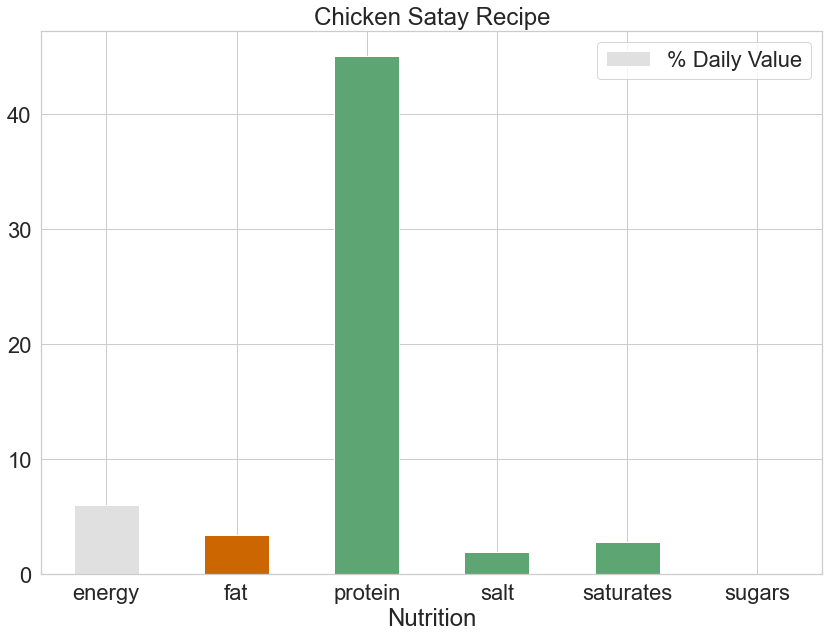

In [66]:
def PlotNutritionDV(NtrOptimize_df):
    color = NtrColor(NtrOptimize_df)
    ntr_plot = pd.DataFrame({'Nutrition':['energy', 'fat', 'protein', 'salt', 'saturates', 'sugars'], 
                             '% Daily Value':[NtrOptimize_df['%DV-energy'].iloc[0], 
                                              NtrOptimize_df['%DV-fat'].iloc[0], 
                                              NtrOptimize_df['%DV-protein'].iloc[0],
                                              NtrOptimize_df['%DV-salt'].iloc[0],
                                              NtrOptimize_df['%DV-saturates'].iloc[0],
                                              NtrOptimize_df['%DV-sugars'].iloc[0]]})
    ntr_plot.plot.bar(x='Nutrition', y='% Daily Value', title=NtrOptimize_df['food'][0], rot=0, color=color)
    
    #heper function
def NtrColor(NtrOptimize_df):
    color = []
    col = '#E0E0E0'
    for column in NtrOptimize_df:
        if column in ['%DV-salt', '%DV-saturates', '%DV-sugars']:
            if NtrOptimize_df[column].iloc[0] < 5.0:
                col = '#5DA573'
            elif (NtrOptimize_df[column].iloc[0] >= 5.0) and (NtrOptimize_df[column].iloc[0] < 20.0):
                col = '#FFCC99'
            else:
                col = '#CC6600'
            
        elif column in ['%DV-fat', '%DV-protein']:
            if NtrOptimize_df[column].iloc[0] < 5.0:
                col = '#CC6600'
            elif (NtrOptimize_df[column].iloc[0] >= 5.0) and (NtrOptimize_df[column].iloc[0] < 20.0):
                col = '#B1D1BA'
            elif NtrOptimize_df[column].iloc[0] >= 20.0:
                col = '#5DA573'

        color.append(col)
    return color[2:]

plot = PlotNutritionDV(nutrional_opt_df)

# Visualize Flavor Space

In [67]:
SPACE_SIZE = 10000 # Adjust based on broswer performance capability
projection_df = pd.DataFrame(projection[:SPACE_SIZE], columns=('x', 'y','z'))
projection_df['id'] = model.dv.index_to_key[:SPACE_SIZE]
projection_df['food'] = df['food'][:SPACE_SIZE]
projection_df['type'] = df['type'][:SPACE_SIZE]
projection_df['ingredient'] = df['unique_ingredient'][:SPACE_SIZE]
projection_df['ingredient_count'] = df['ingredient_count'][:SPACE_SIZE]
projection_df['cluster'] = clustering_df['cluster']
projection_df['color'] = projection_df['cluster'].apply(lambda v: tuple(rgba((v,0))[0:3]))

selected_indexes = []

In [68]:
## find nearest neighbors
def findSimilars(food="", type_="recipe", limit=0):
    if food == "":
        return projection_df, pd.DataFrame(columns=projection_df.columns)
    if not type_ in ["recipe", "ingredient", "all"]:
        raise Exception("Wrong food type, type must be one of 'recipe, ingredient, all' ")
    i=3
    row = df.loc[df['food']==food]
    flavor_vec = model.infer_vector(row.iloc[0]['mol_doc'].words)
    if gensim_version >= 4:
        similars = model.dv.most_similar(positive=[flavor_vec],topn=30)
    else:
        similars = model.dv.most_similar(flavor_vec,topn=30)
    indices = [x[0] for x in similars]
    indices.append(row["id"].iloc[0])
    selected_df = projection_df[projection_df["id"].isin(indices)]
    selected_df = selected_df[selected_df["type"] == type_]
    if type_ == 'recipe':
        selected_df = selected_df[selected_df['ingredient_count'] > limit]
    selected_df = selected_df.iloc[:10]
    nonselected_df = projection_df[~projection_df["id"].isin(selected_df['id'])]
    return nonselected_df, selected_df

In [69]:
np.warnings.filterwarnings('ignore', category=np.VisibleDeprecationWarning)                 

fig = figure(
    title='UMAP projection of the Flavor Space',
    plot_width=800,
    plot_height=600,
    tools=('pan, wheel_zoom, reset, lasso_select')
)

fig.add_tools(HoverTool(tooltips="""
<div>
    <div>
        <span style='font-size: 16px; color: #224499'>ID: @id</span>
        <span style='font-size: 18px'>@food</span>
    </div>
</div>
"""))

## prepare data
nonselected_df, selected_df = findSimilars()
chart_data = ColumnDataSource(nonselected_df)
highlighted_data = ColumnDataSource(selected_df)
table_data = ColumnDataSource(dict(id=highlighted_data.data["id"], 
                           food=highlighted_data.data["food"], 
                           type=highlighted_data.data["type"], 
                           ingredient = highlighted_data.data["ingredient"],
                           ingredient_count=highlighted_data.data["ingredient_count"]
                          ))
color_map = LinearColorMapper(palette=Magma256, low=projection_df['cluster'].min(), high=projection_df['cluster'].max())
marker_map = CategoricalMarkerMapper(factors=projection_df['type'].unique(), markers=['circle', 'triangle'])

chart = fig.scatter(
    'x',
    'y',
    source=chart_data,
    marker=dict(field='type', transform=marker_map),
    fill_color='color',
    line_color=None,
    size=6
)

## drawing scatter of selected data in red color
highlighted_chart = fig.scatter(
    'x',
    'y',
    source=highlighted_data,
    color="pink",
    line_color="black",
    fill_alpha=0.7,
    size=15
)




chart_data.selected.js_on_change('indices', 
     CustomJS(args=dict(chart_data=chart_data, table_data=table_data), 
              code="""
                var selected_indexes = cb_obj.indices;
                console.log(selected_indexes)
                table_data.data['index'] = selected_indexes;
                table_data.data['id'] = [];
                table_data.data['food'] = [];
                table_data.data['ingredient'] = [];
                table_data.data['ingredient_count'] = [];
                table_data.data['type'] = [];
                for (let i=0;i<selected_indexes.length;i++){
                    table_data.data['id'].push(chart_data.data['id'][selected_indexes[i]]);
                    table_data.data['food'].push(chart_data.data['food'][selected_indexes[i]]);
                    table_data.data['type'].push(chart_data.data['type'][selected_indexes[i]]);
                    table_data.data['ingredient'].push(chart_data.data['ingredient'][selected_indexes[i]]);
                    table_data.data['ingredient_count'].push(chart_data.data['ingredient_count'][selected_indexes[i]]);
                }                
                
                // var kernel = IPython.notebook.kernel;
                // IPython.notebook.kernel.execute("selected_indexes = " + selected_indexes);
                
                table_data.change.emit();
                """
             )
)

## display the selected data
table = DataTable(source=table_data, sizing_mode="stretch_width", columns=[
    TableColumn(field='id'),
    TableColumn(field='food'),
    TableColumn(field='type'),
    TableColumn(field='ingredient'),
    TableColumn(field='ingredient_count'),
])

#### config user input widgets
def updateData(food, type_, limit):
    nonselected_df, selected_df = findSimilars(food=food, type_=type_, limit=int(limit))
    # update data
    chart_data.data = nonselected_df
    highlighted_data.data = selected_df
    table_data.data = dict(id=highlighted_data.data["id"], 
                           food=highlighted_data.data["food"], 
                           ingredient = highlighted_data.data["ingredient"],
                           ingredient_count=highlighted_data.data["ingredient_count"],
                           type=highlighted_data.data["type"]
                          )

    
## text input for food input
def text_input_callback(attr, old, new):
    updateData(food=text_input.value, type_=select_type_filter.value, limit=int(select_ingredient_filter.value))

# get all possible entries
recipe_list = df[df['type'] == "recipe"]["food"].tolist()
ingr_list = df[df['type'] == "ingredient"]["food"].tolist()

text_input = AutocompleteInput(title="Food Name", value='', completions=recipe_list, case_sensitive=False)       
text_input.on_change("value",text_input_callback)


## filtration food with only 1 or 2 ingredients
def ingredient_filter_callback(attr, old, new):
    updateData(food=text_input.value, type_=select_type_filter.value, limit=int(select_ingredient_filter.value))

select_ingredient_filter = Slider(start=0, end=5, value=0, step=1, title="Food with at least N ingredients")
select_ingredient_filter.on_change("value", ingredient_filter_callback)


## type filtration
def type_filter_callback(attr, old, new):
    if select_type_filter.value == 'recipe':
        text_input.completions = recipe_list
    else:
        text_input.completions = ingr_list
    text_input.value = ""
    updateData(food=text_input.value, type_=select_type_filter.value, limit=int(select_ingredient_filter.value))
    
select_type_filter = Select(title="Food type", value="recipe", options=["recipe", "ingredient"])
select_type_filter.on_change("value", type_filter_callback)


## Nutrition Optimizer
nutrition_fig = figure(
    x_range=['%DV-energy','%DV-fat','%DV-protein','%DV-salt','%DV-saturates','%DV-sugars'],
    y_range=[0,100],
    title='Healthy Choice Nutrition Profile',
    plot_width=400,
    plot_height=400,
    toolbar_location=None,
    tools=''
)

nutrition_heading = Div(text='<h3>Nutrional Rankings (%Daily Value) -- higher is better</h3>')
nutrition_fig.toolbar.logo = None
nutrition_fig.toolbar_location = None
nutrition_data = ColumnDataSource()
nutrition_chart_data = ColumnDataSource(data=dict(nut=[], dv=[]))
nutrition_table = DataTable(
    source=nutrition_data, 
    width=500, 
    index_position=None,
    columns=[
        TableColumn(field='food', width=200),
        TableColumn(field='%DV-energy', title='energy', width=50),
        TableColumn(field='%DV-fat', title='fat', width=50),
        TableColumn(field='%DV-protein', title='protein', width=50),
        TableColumn(field='%DV-salt', title='salt', width=50),
        TableColumn(field='%DV-saturates', title='sat.', width=50),
        TableColumn(field='%DV-sugars', title='sugar', width=50)
])

nutrition_fig.vbar(
    x='nut',
    top='dv',
    width=0.9,
    source=nutrition_chart_data
)
nutrition_fig.xaxis.major_label_orientation = "vertical"

def nutrition_filter_callback(attr, old, new):
    ###############
    #### placeholder optimization algorithm here!
    ##############
    n_df = NutritionOptimize(highlighted_data.data, df, select_nutrition_filter.value)
    nutrition_data.data = n_df
    top1 = n_df.drop(columns=['id', 'food']).iloc[0]
    nutrition_chart_data.data['nut'] = top1.index.tolist()
    nutrition_chart_data.data['dv'] = top1.values.tolist()
    nutrition_fig.title.text = n_df.iloc[0]['food']
    

select_nutrition_filter = Select(title="Nutrition Priority", value="Select One", options=["Select One", "Default", "Ketogenic", "Low Fat"])
select_nutrition_filter.on_change("value", nutrition_filter_callback)


# Set up layouts and add to document

layout = row(column(row(column(select_type_filter, text_input), column(select_ingredient_filter,select_nutrition_filter)), fig),column(table, nutrition_heading, row(nutrition_table, nutrition_fig)))

def modify_doc(doc):
    doc.add_root(row(layout, width=800))
    return doc


handler = FunctionHandler(modify_doc) # A Handler that accepts a plain python function to use for modifying Bokeh Documents.
app = Application(handler)
show(app)

# "Tastes like Chicken!"

In [70]:
def ingredient_filtered(row, term=''):
    if type(row) == float or row is None:
        return True
    
    for el in row:
        if term in el:
            return True
    return False

def tastes_like(flavor_index, exclude_ingredient, topn=5):
    row = df.iloc[flavor_index]
    flavor_vec = model.dv.vectors[flavor_index]
    if gensim_version >= 4:
        df['_sim'] = model.dv.most_similar([flavor_vec], topn=None)
    else:
        df['_sim'] = model.dv.most_similar(flavor_vec, topn=None)
        
    df['_present'] = df['unique_ingredient'].apply(ingredient_filtered, term=exclude_ingredient.lower())    
    return df[~df._present].sort_values(['_sim'], ascending=False)[:topn]
     

In [71]:
QUERY_INDEX = 51507
df.iloc[QUERY_INDEX][['id','food','unique_ingredient']]

id                   ing-272
food                 Chicken
unique_ingredient        NaN
Name: 51507, dtype: object

In [72]:
tastes_like(QUERY_INDEX, exclude_ingredient='Chicken', topn=10)[['id','food','unique_ingredient','_sim']]

,id,food,unique_ingredient,_sim
46151,e67b50494c,Gorilla Fart,"[alcoholic beverage, distilled, rum, 80 proof,...",0.555796
47916,ef4a9bec66,Bbq rotisserie smoked turkey,"[ground turkey, raw]",0.548685
45523,e35bc46e21,Flaming Orgy,"[ground turkey, raw, alcoholic beverage, disti...",0.542926
43140,d7c5341369,Desert Fire,"[alcoholic beverage, tequila sunrise, canned, ...",0.540397
50751,fd74454535,Cajun Deep Fried Turkey (Houston Chronicle) Re...,"[ground turkey, raw]",0.536604
46349,e768b479b4,Thankgiving Day Turkey,"[ground turkey, raw, water, bottled, generic, ...",0.535439
47763,ee8e2ea848,Beef Jerkey,"[beef, flank, steak, separable lean and fat, t...",0.521485
30290,9718087152,How to cook a turkey,"[ground turkey, raw]",0.516030
33357,a643679b3e,Reuben Sandwich,"[ground turkey, raw]",0.515735
32244,a0bd9dade2,70 Minute Butterflied Roast Turkey,"[ground turkey, raw, leavening agents, baking ...",0.515576


# Computational Cooking!

In [73]:
# Locate food vectorsa
df[(df.type == 'ingredient') & (df['food'].str.contains('Potato'))];

## What molecules determine meat flavor?

In [74]:
meat_vec_ids = [51507,51515,51513,51505,51510]
df.iloc[meat_vec_ids]

,id,food,unique_ingredient,ingredient_count,category_freq,instructions,flavor_molecules,molecules_count,nutr_values_per100g.energy,nutr_values_per100g.fat,...,entity_alias_basket,natural_source_name,entity_alias,molecules,natural_source_url,entity_alias_url,entity_alias_synonyms,mol_doc,_sim,_present
51507,ing-272,Chicken,NaN,NaN,NaN,NaN,NaN,131,NaN,NaN,...,"chicken, chicken-boiled, chicken-broth, chicke...",Fowl,chicken,"[{'bond_stereo_count': 2, 'undefined_atom_ster...",https://en.wikipedia.org/wiki/Fowl,https://en.wikipedia.org/wiki/Chicken,Chicken,"([5367531, 20083, 5283349, 7501, 7363, 5352461...",1.000000,True
51515,ing-280,Turkey,NaN,NaN,NaN,NaN,NaN,17,NaN,NaN,...,"turkey, turkey-cooked, turkey-roasted",Domesticate Turkey,turkey,"[{'bond_stereo_count': 0, 'undefined_atom_ster...",https://en.wikipedia.org/wiki/Domesticated_turkey,https://en.wikipedia.org/wiki/Turkey_meat,Turkey,"([6202, 644104, 20861, 6274, 520108, 11449, 52...",0.532577,True
51513,ing-278,Pork,NaN,NaN,NaN,NaN,NaN,157,NaN,NaN,...,"pork, pork-bacon, pork-boiled, pork-cooked, po...",Domestic Pig,pork,"[{'bond_stereo_count': 2, 'undefined_atom_ster...",https://en.wikipedia.org/wiki/Domestic_pig,https://en.wikipedia.org/wiki/Pork,"Pork, Bacon","([5367531, 10558, 61260, 10448, 7363, 8468, 11...",0.481254,True
51505,ing-270,Beef,NaN,NaN,NaN,NaN,NaN,92,NaN,NaN,...,"beef, beef-canned, beef-extract, beef-liver, b...",Cattle,beef,"[{'bond_stereo_count': 0, 'undefined_atom_ster...",https://en.wikipedia.org/wiki/Cattle,https://en.wikipedia.org/wiki/Beef,Beef,"([20083, 7501, 643731, 11509, 985, 1123, 6584,...",0.497251,True
51510,ing-275,Lamb,NaN,NaN,NaN,NaN,NaN,37,NaN,NaN,...,"lamb, lamb-cooked, lamb-fat, lamb-liver, lamb-...",Sheep,lamb,"[{'bond_stereo_count': 0, 'undefined_atom_ster...",https://en.wikipedia.org/wiki/Sheep,https://en.wikipedia.org/wiki/Sheep,Lamb,"([20653, 61840, 62089, 5281, 7909, 5283321, 52...",0.303418,True


In [75]:
def common_mols(vec_ids, common):
    if len(vec_ids) == 1:
        i = vec_ids.pop()
        b = set(df.iloc[i].mols)
        return common.intersection(b)
    else:
        i = vec_ids.pop()
        b = set(df.iloc[i].mols)
        return common_mols(vec_ids, common.intersection(b))

In [76]:
meat_mols = common_mols(meat_vec_ids[1:], set(df.iloc[meat_vec_ids[0]].mols))
meat_vec = model.infer_vector(meat_mols, epochs=100)
if gensim_version >= 4:
    similars = model.dv.most_similar(positive=[meat_vec])
else:
    similars = model.dv.most_similar(meat_vec)
    
s_df = pd.DataFrame(similars, columns=['id','similarity']).astype({'id': 'string'})
s_df.reset_index().merge(df, on='id', how='left')[['id','similarity','food']]

,id,similarity,food
0,ing-316,0.907860,Macaroni
1,ing-273,0.893685,Frankfurter Sausage
2,56b5ef3b8c,0.820585,Baked Brie Recipe
3,ing-274,0.818990,Ham
4,ing-61,0.645441,Buttermilk
5,e35bc46e21,0.633718,Flaming Orgy
6,ing-1,0.633482,Bakery Products
7,ing-280,0.628930,Turkey
8,e768b479b4,0.625515,Thankgiving Day Turkey
9,fd74454535,0.619030,Cajun Deep Fried Turkey (Houston Chronicle) Re...


## Finding the perfect snack

In [77]:
food_vec_ids = [51522,51550,51608]
df.iloc[food_vec_ids]

,id,food,unique_ingredient,ingredient_count,category_freq,instructions,flavor_molecules,molecules_count,nutr_values_per100g.energy,nutr_values_per100g.fat,...,entity_alias_basket,natural_source_name,entity_alias,molecules,natural_source_url,entity_alias_url,entity_alias_synonyms,mol_doc,_sim,_present
51522,ing-287,Peanut,NaN,NaN,NaN,NaN,NaN,212,NaN,NaN,...,"peanut, peanut-roasted",Arachis,peanut,"[{'bond_stereo_count': 1, 'undefined_atom_ster...",https://en.wikipedia.org/wiki/Arachis,https://en.wikipedia.org/wiki/Peanut,"Groundnut, Goober","([6436017, 5367531, 323, 107971, 12779, 7501, ...",0.227586,True
51550,ing-315,Honey,NaN,NaN,NaN,NaN,NaN,60,NaN,NaN,...,honey,Bees,honey,"[{'bond_stereo_count': 0, 'undefined_atom_ster...",https://en.wikipedia.org/wiki/Bee,https://en.wikipedia.org/wiki/Honey,Honey,"([7362, 12529, 7795, 11124, 7501, 12180, 7150,...",0.369025,True
51608,ing-373,Potato,NaN,NaN,NaN,NaN,NaN,254,NaN,NaN,...,"potato, potato-baked, potato-boiled, potato-ca...",Solanum,potato,"[{'bond_stereo_count': 0, 'undefined_atom_ster...",https://en.wikipedia.org/wiki/Solanum,https://en.wikipedia.org/wiki/Potato,Potato,"([323, 107971, 12209, 5283349, 7284, 10448, 71...",0.306704,True


In [78]:
peanut = model.dv.vectors[51522]
honey = 0.5*model.dv.vectors[51550]
potato = model.dv.vectors[51608]

In [79]:
if gensim_version >= 4:
    similars = model.dv.most_similar(positive=[peanut+honey+meat_vec-potato])
else:
    similars = model.dv.most_similar(peanut+honey+meat_vec-potato)
    
s_df = pd.DataFrame(similars, columns=['id','similarity']).astype({'id': 'string'})
s_df.reset_index().merge(df, on='id', how='left')[['id','similarity','food']]

,id,similarity,food
0,ing-287,0.591035,Peanut
1,22a5431b8f,0.475267,Injectable Brine for Turkey/Chicken
2,b550bd0510,0.474924,Chinese Salad Dressing
3,5655af03ca,0.472363,Simplest Chocolate Honey Mousse
4,0701eaacca,0.469700,Our Favorite Honey Mustard Dipping Sauce
5,51ba0db734,0.468939,Honeyed Walnuts
6,2b554594b7,0.468650,Conjunctivitis (Honey Eye Bath)
7,ing-315,0.468171,Honey
8,03f1304925,0.467697,Basic French Dough Recipe
9,69f70a9023,0.466702,Sweet Pork Chop Sauce


# Save Flavor Space Artifacts

In [80]:
if not LOAD_FROM_FILE:
    df.drop(columns=['mol_doc']+[c for c in df.columns if c.startswith('_')]).to_parquet(DATAFRAME_FILE)
    mol_df.to_parquet(FLAVMOL_FILE)

In [54]:
df

,id,food,unique_ingredient,ingredient_count,category_freq,instructions,flavor_molecules,molecules_count,nutr_values_per100g.energy,nutr_values_per100g.fat,...,category,category_readable,entity_alias_basket,natural_source_name,entity_alias,molecules,natural_source_url,entity_alias_url,entity_alias_synonyms,mol_doc
0,005e671ac4,Pecan Pralines,"[cream, fluid, heavy whipping, sugars, brown, ...",5.0,"[{'additive': 1}, {'dairy': 2}, {'fruit-essenc...",[{'text': 'Butter a medium saucepan--this will...,"[{'ingredient_flavorDB': 'Vanilla', 'fooddb_id...",261,435.964748,24.989687,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"([247, 11552, 7501, 9895, 644104, 7519, 11508,..."
1,00703db954,Greatest Granola,"[oats, seeds, sesame seeds, whole, dried, seed...",8.0,"[{'additive': 1}, {'cerealcrop-cereal': 1}, {'...","[{'text': 'Preheat oven to 300F.'}, {'text': '...","[{'ingredient_flavorDB': 'Sesame', 'fooddb_id'...",306,580.155727,48.485788,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"([5283335, 439246, 72, 5283329, 180, 8130, 439..."
2,007e544c80,Cream of Fresh Cauliflower Soup,"[soup, chicken broth or bouillon, dry, onions,...",9.0,"[{'additive': 1}, {'cerealcrop-cereal': 1}, {'...","[{'text': 'In a saucepan, combine the chicken ...","[{'ingredient_flavorDB': 'Milk', 'fooddb_id': ...",506,67.292099,2.138987,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"([985, 261, 7288, 643941, 439341, 8103, 62367,..."
3,00a0ea8691,Sausage and Rice Bake,"[rice, white, long-grain, regular, unenriched,...",9.0,"[{'additive': 1}, {'cerealcrop-cereal': 1}, {'...","[{'text': 'In a shallow 2 qt casserole, place ...","[{'ingredient_flavorDB': 'Rice', 'fooddb_id': ...",470,123.633639,10.130253,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"([10393, 6140, 442501, 18698, 33931, 65575, 61..."
4,00deb3f9f4,Spicy Raspberry Balsamic Dressing,"[oil, olive, salad or cooking, vinegar, balsam...",9.0,"[{'additive': 1}, {'fruit-berry': 1}, {'nutsee...","[{'text': 'Whisk olive oil, balsamic vinegar, ...","[{'ingredient_flavorDB': 'Raspberry', 'fooddb_...",462,569.663693,60.804892,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"([5282708, 637511, 10931, 998, 14896, 7460, 72..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1929,ing-968,Green zucchini,NaN,NaN,NaN,NaN,NaN,107,NaN,NaN,...,vegetable,Vegetable,,Cucurbita_pepo,,"[{'bond_stereo_count': 0, 'undefined_atom_ster...",https://en.wikipedia.org/wiki/Cucurbita_pepo,https://en.wikipedia.org/wiki/Zucchini,Courgette,"([323, 107971, 7284, 10448, 7150, 638011, 8468..."
1930,ing-969,Yellow zucchini,NaN,NaN,NaN,NaN,NaN,103,NaN,NaN,...,vegetable,Vegetable,,Cucurbita_pepo,,"[{'bond_stereo_count': 0, 'undefined_atom_ster...",https://en.wikipedia.org/wiki/Cucurbita_pepo,https://en.wikipedia.org/wiki/Zucchini,Yellow zucchini,"([323, 107971, 7284, 10448, 7150, 638011, 1150..."
1931,ing-970,Saskatoon berry,NaN,NaN,NaN,NaN,NaN,94,NaN,NaN,...,fruit-berry,Berry,,Amelanchier,,"[{'bond_stereo_count': 0, 'undefined_atom_ster...",https://en.wikipedia.org/wiki/Amelanchier,https://en.wikipedia.org/wiki/Amelanchier_alni...,"Saskatoon, Pacific serviceberry, Western serv...","([323, 107971, 7284, 10448, 7150, 638011, 1150..."
1932,ing-971,Nanking cherry,NaN,NaN,NaN,NaN,NaN,94,NaN,NaN,...,fruit-berry,Berry,,Prunus cerasus,,"[{'bond_stereo_count': 0, 'undefined_atom_ster...",https://en.wikipedia.org/wiki/Prunus_cerasus,https://en.wikipedia.org/wiki/Prunus_tomentosa,"Korean cherry, Manchu cherry, Downy cherry, Sh...","([323, 107971, 7284, 10448, 7150, 638011, 1150..."
